# MOMENTS dataset exploration

This notebook helps inspect the structure of the MOMENTS dataset and answer common sanity-check questions before running experiments.

It covers:

- dataset root validation
- number of matches
- number of important vs non-important moments
- counts of `.mp4`, `.wav`, and `.json` files
- folder structure inspection
- sample-level integrity checks
- per-match summary table

Update `DATASET_ROOT` below if needed.

In [1]:
import cv2
cap = cv2.VideoCapture('/home/eboccaletti/thesis_project/data/MOMENTS/06FNvY2s/important-moments/1/IM_1.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'FPS: {fps}, Total frames: {frames}, Duration: {frames/fps:.2f}s')
cap.release()

FPS: 30.067498465943956, Total frames: 441, Duration: 14.67s


In [ ]:
import os, json, glob
scores = []
for f in glob.glob('/home/eboccaletti/thesis_project/data/MOMENTS/*/*/*/*_v1.json'):
    try:
        d = json.load(open(f))
        scores.append(d['similarity'])
    except: pass
scores.sort()
print(f'Total: {len(scores)}')
print(f'Min: {min(scores):.3f}, Max: {max(scores):.3f}, Average: {sum(scores)/len(scores):.3f}')
print(f'<0.3: {sum(1 for s in scores if s < 0.3)}')
print(f'<0.5: {sum(1 for s in scores if s < 0.5)}')
print(f'>0.7: {sum(1 for s in scores if s > 0.7)}')
print(f'>0.9: {sum(1 for s in scores if s > 0.9)}')

Total: 3954
Min: -0.049, Max: 1.000, Average: 0.785
<0.3: 311
<0.5: 479
>0.7: 2987
>0.9: 1711


In [ ]:
import os, json, glob
scores2 = []
for f in glob.glob('/home/eboccaletti/thesis_project/data/MOMENTS/*/*/*/*_v2.json'):
  try:
      d = json.load(open(f))
      scores2.append(d['similarity'])
  except: pass
scores2.sort()
print(f'Total: {len(scores2)}')
print(f'Min: {min(scores2):.3f}, Max: {max(scores2):.3f}, Average: {sum(scores2)/len(scores2):.3f}')
print(f'<0.3: {sum(1 for s in scores2 if s < 0.3)}')
print(f'<0.5: {sum(1 for s in scores2 if s < 0.5)}')
print(f'>0.7: {sum(1 for s in scores2 if s > 0.7)}')
print(f'>0.9: {sum(1 for s in scores2 if s > 0.9)}')

Total: 3954
Min: -0.134, Max: 1.000, Average: 0.829
<0.3: 161
<0.5: 264
>0.7: 3284
>0.9: 1861


In [ ]:
import os, json, glob
all_jscores = []
for f in glob.glob('/home/eboccaletti/thesis_project/data/MOMENTS/*/*/*/*.json'):
  try:
      d = json.load(open(f))
      all_jscores.append(d['similarity'])
  except: pass
all_jscores.sort()
print(f'Total: {len(all_jscores)}')
print(f'Min: {min(all_jscores):.3f}, Max: {max(all_jscores):.3f}, Average: {sum(all_jscores)/len(all_jscores):.3f}')
print(f'<0.3: {sum(1 for s in all_jscores if s < 0.3)}')
print(f'<0.5: {sum(1 for s in all_jscores if s < 0.5)}')
print(f'>0.7: {sum(1 for s in all_jscores if s > 0.7)}')
print(f'>0.9: {sum(1 for s in all_jscores if s > 0.9)}')

Total: 7908
Min: -0.134, Max: 1.000, Average: 0.807
<0.3: 472
<0.5: 743
>0.7: 6271
>0.9: 3572


In [5]:
from pathlib import Path
import os
import json
from collections import defaultdict, Counter
import pandas as pd

DATASET_ROOT = Path("/home/eboccaletti/thesis_project/data/MOMENTS")
print("Dataset root:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Dataset root: /home/eboccaletti/thesis_project/data/MOMENTS
Exists: True


In [6]:
match_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])
print("Number of match folders:", len(match_dirs))
print("First 10 match ids:", [p.name for p in match_dirs[:10]])

Number of match folders: 100
First 10 match ids: ['06FNvY2s', '0Glu8uEj', '0jJj5Mme', '0rkvoaKm', '27mkIPyb', '29Qtz4MD', '4IUxUAwJ', '4rxwHJn7', '4tJXu8C7', '63fde7Re']


In [7]:
rows = []
missing_local = 0
missing_global = 0
missing_similarity = 0
bad_json = 0

for path in DATASET_ROOT.rglob("*.json"):
    try:
        with path.open() as f:
            d = json.load(f)
    except Exception:
        bad_json += 1
        continue

    if not isinstance(d, dict):
        bad_json += 1
        continue

    local_text = str(d.get("local", "")).strip()
    global_text = str(d.get("global", "")).strip()
    similarity = d.get("similarity", None)

    if not local_text:
        missing_local += 1
    if not global_text:
        missing_global += 1
    if similarity is None:
        missing_similarity += 1
        continue
    try:
        similarity = float(similarity)
    except Exception:
        missing_similarity += 1
        continue

    label = "unknown"
    if "important-moments" in path.parts:
        label = "important"
    elif "non-important-moments" in path.parts:
        label = "non-important"

    variant = "unknown"
    if path.name.endswith("_v1.json"):
        variant = "v1"
    elif path.name.endswith("_v2.json"):
        variant = "v2"

    rows.append(
        {"path": str(path),
       "label": label,
       "variant": variant,
       "similarity": similarity,
       "local_text": local_text,
       "global_text": global_text,
       })

df = pd.DataFrame(rows)

print("=== Overall ===")
print("json files read:", len(rows))
print("bad json files:", bad_json)
print("missing local text:", missing_local)
print("missing global text:", missing_global)
print("missing similarity:", missing_similarity)
print()

print("=== Similarity thresholds ===")
print(">= 0.9:", int((df["similarity"] >= 0.9).sum()))
print(">= 0.8:", int((df["similarity"] >= 0.8).sum()))
print("< 0.5:", int((df["similarity"] < 0.5).sum()))
print("< 0.3:", int((df["similarity"] < 0.3).sum()))
print()

print("=== By label ===")
print(df.groupby("label")["similarity"].agg(["count", "min", "mean", "max"]).round(4))
print()

print("=== By variant ===")
print(df.groupby("variant")["similarity"].agg(["count", "min", "mean","max"]).round(4))
print()

print("=== Duplicate transcript pairs ===")
pair_counts = Counter((r["local_text"], r["global_text"]) for _, r in df.iterrows())
dup_pairs = sum(1 for c in pair_counts.values() if c > 1)
print("unique local/global transcript pairs:", len(pair_counts))
print("duplicate pairs:", dup_pairs)
print()

print("=== Lowest similarity examples ===")
display(df.sort_values("similarity", ascending=True)[
    ["similarity", "label", "variant", "path"]
    ].head(20))

=== Overall ===
json files read: 7908
bad json files: 0
missing local text: 3
missing global text: 26
missing similarity: 0

=== Similarity thresholds ===
>= 0.9: 3572
>= 0.8: 5277
< 0.5: 743
< 0.3: 472

=== By label ===
               count     min    mean  max
label                                    
important       3954 -0.0341  0.8383  1.0
non-important   3954 -0.1337  0.7757  1.0

=== By variant ===
         count     min    mean  max
variant                            
v1        3954 -0.0490  0.7849  1.0
v2        3954 -0.1337  0.8290  1.0

=== Duplicate transcript pairs ===
unique local/global transcript pairs: 7852
duplicate pairs: 53

=== Lowest similarity examples ===


,similarity,label,variant,path
1815,-0.133694,non-important,v2,/home/eboccaletti/thesis_project/data/MOMENTS/...
6556,-0.067615,non-important,v2,/home/eboccaletti/thesis_project/data/MOMENTS/...
1086,-0.049023,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
1397,-0.047171,non-important,v2,/home/eboccaletti/thesis_project/data/MOMENTS/...
5840,-0.042840,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
6559,-0.040835,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
1793,-0.040053,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
883,-0.034110,important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
6001,-0.020907,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...
3643,-0.013345,non-important,v1,/home/eboccaletti/thesis_project/data/MOMENTS/...


### Quick recursive file counts

In [8]:
def count_files(root: Path, pattern: str):
    return sum(1 for _ in root.rglob(pattern))

summary = {
    "mp4_files": count_files(DATASET_ROOT, "*.mp4"),
    "wav_files": count_files(DATASET_ROOT, "*.wav"),
    "json_files": count_files(DATASET_ROOT, "*.json"),
}

summary

{'mp4_files': 3954, 'wav_files': 7908, 'json_files': 7908}

### Count important vs non-important moments

A moment is counted by its `.mp4` file.

In [9]:
important_mp4 = list(DATASET_ROOT.rglob("important-moments/*/*.mp4"))
nonimportant_mp4 = list(DATASET_ROOT.rglob("non-important-moments/*/*.mp4"))

print("Important moments (.mp4):", len(important_mp4))
print("Non-important moments (.mp4):", len(nonimportant_mp4))
print("Total moments (.mp4):", len(important_mp4) + len(nonimportant_mp4))

Important moments (.mp4): 1977
Non-important moments (.mp4): 1977
Total moments (.mp4): 3954


### Inspect one match folder

In [10]:
example_match = match_dirs[0]
print("Example match:", example_match.name)

for child in sorted(example_match.iterdir()):
    print("-", child.name)
    if child.is_dir():
        for p in sorted(child.iterdir()):
            print("  subfolders:", p.name)
            if p.is_dir():
                print(f"    items in subfolder {p.name}:", [c.name for c in sorted(p.iterdir())])
        # print("  subfolders:", [p.name for p in sorted(child.iterdir())])

Example match: 06FNvY2s
- important-moments
  subfolders: 1
    items in subfolder 1: ['IM_1.mp4', 'IM_1_v1.json', 'IM_1_v1.wav', 'IM_1_v2.json', 'IM_1_v2.wav', 'IM_2.mp4', 'IM_2_v1.json', 'IM_2_v1.wav', 'IM_2_v2.json', 'IM_2_v2.wav', 'IM_3.mp4', 'IM_3_v1.json', 'IM_3_v1.wav', 'IM_3_v2.json', 'IM_3_v2.wav', 'IM_4.mp4', 'IM_4_v1.json', 'IM_4_v1.wav', 'IM_4_v2.json', 'IM_4_v2.wav']
  subfolders: 2
    items in subfolder 2: ['IM_1.mp4', 'IM_10.mp4', 'IM_10_v1.json', 'IM_10_v1.wav', 'IM_10_v2.json', 'IM_10_v2.wav', 'IM_11.mp4', 'IM_11_v1.json', 'IM_11_v1.wav', 'IM_11_v2.json', 'IM_11_v2.wav', 'IM_12.mp4', 'IM_12_v1.json', 'IM_12_v1.wav', 'IM_12_v2.json', 'IM_12_v2.wav', 'IM_13.mp4', 'IM_13_v1.json', 'IM_13_v1.wav', 'IM_13_v2.json', 'IM_13_v2.wav', 'IM_14.mp4', 'IM_14_v1.json', 'IM_14_v1.wav', 'IM_14_v2.json', 'IM_14_v2.wav', 'IM_1_v1.json', 'IM_1_v1.wav', 'IM_1_v2.json', 'IM_1_v2.wav', 'IM_2.mp4', 'IM_2_v1.json', 'IM_2_v1.wav', 'IM_2_v2.json', 'IM_2_v2.wav', 'IM_3.mp4', 'IM_3_v1.json', 'IM

### Per-match summary table

In [11]:
rows = []

for match_dir in match_dirs:
    imp = list(match_dir.rglob("important-moments/*/*.mp4"))
    nim = list(match_dir.rglob("non-important-moments/*/*.mp4"))
    wav = list(match_dir.rglob("*.wav"))
    js = list(match_dir.rglob("*.json"))
    js1 = list(match_dir.rglob("*_v1.json"))
    js2 = list(match_dir.rglob("*_v2.json"))
    rows.append({
        "match_id": match_dir.name,
        "important_mp4": len(imp),
        "nonimportant_mp4": len(nim),
        "total_mp4": len(imp) + len(nim),
        "wav_files": len(wav),
        "json_files": len(js),
        "json_files_v1": len(js1),
        "json_files_v2": len(js2),
    })

df = pd.DataFrame(rows).sort_values(["total_mp4", "match_id"], ascending=[False, True]).reset_index(drop=True)
df.head(10)

,match_id,important_mp4,nonimportant_mp4,total_mp4,wav_files,json_files,json_files_v1,json_files_v2
0,CWsmcDnK,52,52,104,208,208,104,104
1,bevos1dM,45,45,90,180,180,90,90
2,0jJj5Mme,40,40,80,160,160,80,80
3,Q3ZH0ngC,38,38,76,152,152,76,76
4,4rxwHJn7,37,37,74,148,148,74,74
5,d6KTKRH2,33,33,66,132,132,66,66
6,UcZVYDFH,31,31,62,124,124,62,62
7,IwW928Oa,29,29,58,116,116,58,58
8,dbbAV6hn,28,28,56,112,112,56,56
9,l0uNkr78,28,28,56,112,112,56,56


In [12]:
print("Matches with largest number of moment clips:")
df[["match_id", "important_mp4", "nonimportant_mp4", "total_mp4"]].head(15)

Matches with largest number of moment clips:


,match_id,important_mp4,nonimportant_mp4,total_mp4
0,CWsmcDnK,52,52,104
1,bevos1dM,45,45,90
2,0jJj5Mme,40,40,80
3,Q3ZH0ngC,38,38,76
4,4rxwHJn7,37,37,74
5,d6KTKRH2,33,33,66
6,UcZVYDFH,31,31,62
7,IwW928Oa,29,29,58
8,dbbAV6hn,28,28,56
9,l0uNkr78,28,28,56


In [13]:
rows = []

for match_dir in match_dirs:

    imp1 = list((match_dir / "important-moments/1").rglob("*.mp4"))
    imp2 = list((match_dir / "important-moments/2").rglob("*.mp4"))

    nim1 = list((match_dir / "non-important-moments/1").rglob("*.mp4"))
    nim2 = list((match_dir / "non-important-moments/2").rglob("*.mp4"))

    wav = list(match_dir.rglob("*.wav"))
    js = list(match_dir.rglob("*.json"))

    rows.append({
        "match_id": match_dir.name,

        "important_1_mp4": len(imp1),
        "important_2_mp4": len(imp2),
        "important_total": len(imp1) + len(imp2),

        "nonimportant_1_mp4": len(nim1),
        "nonimportant_2_mp4": len(nim2),
        "nonimportant_total": len(nim1) + len(nim2),

        "total_mp4": len(imp1) + len(imp2) + len(nim1) + len(nim2),

        "wav_files": len(wav),
        "json_files": len(js),
    })

df_1_2 = (
    pd.DataFrame(rows)
    .sort_values(["total_mp4", "match_id"], ascending=[False, True])
    .reset_index(drop=True)
)

df_1_2.head(10)

,match_id,important_1_mp4,important_2_mp4,important_total,nonimportant_1_mp4,nonimportant_2_mp4,nonimportant_total,total_mp4,wav_files,json_files
0,CWsmcDnK,24,28,52,29,23,52,104,208,208
1,bevos1dM,15,30,45,15,30,45,90,180,180
2,0jJj5Mme,17,23,40,21,19,40,80,160,160
3,Q3ZH0ngC,23,15,38,23,15,38,76,152,152
4,4rxwHJn7,17,20,37,17,20,37,74,148,148
5,d6KTKRH2,12,21,33,19,14,33,66,132,132
6,UcZVYDFH,19,12,31,26,5,31,62,124,124
7,IwW928Oa,12,17,29,16,13,29,58,116,116
8,dbbAV6hn,13,15,28,18,10,28,56,112,112
9,l0uNkr78,9,19,28,12,16,28,56,112,112


In [14]:
df_1_2

,match_id,important_1_mp4,important_2_mp4,important_total,nonimportant_1_mp4,nonimportant_2_mp4,nonimportant_total,total_mp4,wav_files,json_files
0,CWsmcDnK,24,28,52,29,23,52,104,208,208
1,bevos1dM,15,30,45,15,30,45,90,180,180
2,0jJj5Mme,17,23,40,21,19,40,80,160,160
3,Q3ZH0ngC,23,15,38,23,15,38,76,152,152
4,4rxwHJn7,17,20,37,17,20,37,74,148,148
...,...,...,...,...,...,...,...,...,...,...
95,dSLaBHOD,5,4,9,7,2,9,18,36,36
96,27mkIPyb,1,5,6,4,2,6,12,24,24
97,dKZ3Hnnt,2,3,5,2,3,5,10,20,20
98,G6H5dOXR,3,1,4,3,1,4,8,16,16


In [15]:
print(df_1_2["important_1_mp4"].max())
print(df_1_2["important_2_mp4"].max())
print(df_1_2["nonimportant_1_mp4"].max())
print(df_1_2["nonimportant_2_mp4"].max())

print(df_1_2.loc[df_1_2["nonimportant_2_mp4"].idxmax()])
print(df_1_2.loc[df_1_2["important_1_mp4"].idxmax()])

24
30
29
30
match_id              bevos1dM
important_1_mp4             15
important_2_mp4             30
important_total             45
nonimportant_1_mp4          15
nonimportant_2_mp4          30
nonimportant_total          45
total_mp4                   90
wav_files                  180
json_files                 180
Name: 1, dtype: object
match_id              CWsmcDnK
important_1_mp4             24
important_2_mp4             28
important_total             52
nonimportant_1_mp4          29
nonimportant_2_mp4          23
nonimportant_total          52
total_mp4                  104
wav_files                  208
json_files                 208
Name: 0, dtype: object


In [16]:
print(df_1_2["important_1_mp4"].min())
print(df_1_2["important_2_mp4"].min())
print(df_1_2["nonimportant_1_mp4"].min())
print(df_1_2["nonimportant_2_mp4"].min())

print(df_1_2.loc[df_1_2["nonimportant_2_mp4"].idxmin()])
print(df_1_2.loc[df_1_2["important_1_mp4"].idxmin()])

0
1
0
1
match_id              G6H5dOXR
important_1_mp4              3
important_2_mp4              1
important_total              4
nonimportant_1_mp4           3
nonimportant_2_mp4           1
nonimportant_total           4
total_mp4                    8
wav_files                   16
json_files                  16
Name: 98, dtype: object
match_id              KvKpGOqN
important_1_mp4              0
important_2_mp4              4
important_total              4
nonimportant_1_mp4           0
nonimportant_2_mp4           4
nonimportant_total           4
total_mp4                    8
wav_files                   16
json_files                  16
Name: 99, dtype: object


In [17]:
df_1_2[["important_total","nonimportant_total"]].describe()

,important_total,nonimportant_total
count,100.000000,100.000000
mean,19.770000,19.770000
std,7.783504,7.783504
min,4.000000,4.000000
25%,15.000000,15.000000
50%,18.000000,18.000000
75%,23.250000,23.250000
max,52.000000,52.000000


### Source folders `1` and `2`

This checks whether each match has both source folders inside `important-moments` and `non-important-moments`.

In [18]:
source_rows = []

for match_dir in match_dirs:
    for label in ["important-moments", "non-important-moments"]:
        label_dir = match_dir / label
        source_rows.append({
            "match_id": match_dir.name,
            "label": label,
            "has_1": (label_dir / "1").exists(),
            "has_2": (label_dir / "2").exists(),
            "sources_present": [p.name for p in sorted(label_dir.iterdir()) if p.is_dir()] if label_dir.exists() else []
        })

sources_df = pd.DataFrame(source_rows)
sources_df.head(8)

,match_id,label,has_1,has_2,sources_present
0,06FNvY2s,important-moments,True,True,"[1, 2]"
1,06FNvY2s,non-important-moments,True,True,"[1, 2]"
2,0Glu8uEj,important-moments,True,True,"[1, 2]"
3,0Glu8uEj,non-important-moments,True,True,"[1, 2]"
4,0jJj5Mme,important-moments,True,True,"[1, 2]"
5,0jJj5Mme,non-important-moments,True,True,"[1, 2]"
6,0rkvoaKm,important-moments,True,True,"[1, 2]"
7,0rkvoaKm,non-important-moments,True,True,"[1, 2]"


### Integrity check: does each `.mp4` have matching `.wav` and `.json` files?

The dataset uses names like:

- `IM_3.mp4`
- `IM_3_v1.wav`
- `IM_3_v1.json`
- `IM_3_v2.wav`
- `IM_3_v2.json`

This cell summarizes, for each moment clip, how many matching audio/transcript variants exist.


In [19]:
def inspect_moment_folder(folder: Path):
    mp4s = sorted(folder.glob("*.mp4"))
    rows = []
    for mp4 in mp4s:
        stem = mp4.stem  # e.g., IM_3 or NIM_2
        wavs = sorted(folder.glob(f"{stem}_v*.wav"))
        jsons = sorted(folder.glob(f"{stem}_v*.json"))
        rows.append({
            "folder": str(folder),
            "moment_id": stem,
            "mp4": mp4.name,
            "n_wav_variants": len(wavs),
            "n_json_variants": len(jsons),
            "wav_files": [p.name for p in wavs],
            "json_files": [p.name for p in jsons],
        })
    return rows

moment_rows = []
for match_dir in match_dirs:
    for folder in match_dir.rglob("*"):
        if folder.is_dir() and folder.name in {"1", "2"} and folder.parent.name in {"important-moments", "non-important-moments"}:
            moment_rows.extend(inspect_moment_folder(folder))

moments_df = pd.DataFrame(moment_rows)
moments_df.head(10)

,folder,moment_id,mp4,n_wav_variants,n_json_variants,wav_files,json_files
0,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_1,NIM_1.mp4,2,2,"[NIM_1_v1.wav, NIM_1_v2.wav]","[NIM_1_v1.json, NIM_1_v2.json]"
1,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_10,NIM_10.mp4,2,2,"[NIM_10_v1.wav, NIM_10_v2.wav]","[NIM_10_v1.json, NIM_10_v2.json]"
2,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_2,NIM_2.mp4,2,2,"[NIM_2_v1.wav, NIM_2_v2.wav]","[NIM_2_v1.json, NIM_2_v2.json]"
3,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_3,NIM_3.mp4,2,2,"[NIM_3_v1.wav, NIM_3_v2.wav]","[NIM_3_v1.json, NIM_3_v2.json]"
4,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_4,NIM_4.mp4,2,2,"[NIM_4_v1.wav, NIM_4_v2.wav]","[NIM_4_v1.json, NIM_4_v2.json]"
5,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_5,NIM_5.mp4,2,2,"[NIM_5_v1.wav, NIM_5_v2.wav]","[NIM_5_v1.json, NIM_5_v2.json]"
6,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_6,NIM_6.mp4,2,2,"[NIM_6_v1.wav, NIM_6_v2.wav]","[NIM_6_v1.json, NIM_6_v2.json]"
7,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_7,NIM_7.mp4,2,2,"[NIM_7_v1.wav, NIM_7_v2.wav]","[NIM_7_v1.json, NIM_7_v2.json]"
8,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_8,NIM_8.mp4,2,2,"[NIM_8_v1.wav, NIM_8_v2.wav]","[NIM_8_v1.json, NIM_8_v2.json]"
9,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_9,NIM_9.mp4,2,2,"[NIM_9_v1.wav, NIM_9_v2.wav]","[NIM_9_v1.json, NIM_9_v2.json]"


In [20]:
print("Distribution of number of audio variants per moment:")
print(moments_df["n_wav_variants"].value_counts().sort_index())

print("\\nDistribution of number of json variants per moment:")
print(moments_df["n_json_variants"].value_counts().sort_index())

Distribution of number of audio variants per moment:
n_wav_variants
2    3954
Name: count, dtype: int64
\nDistribution of number of json variants per moment:
n_json_variants
2    3954
Name: count, dtype: int64


In [21]:
problematic = moments_df[(moments_df["n_wav_variants"] == 0) | (moments_df["n_json_variants"] == 0)]
print("Moments missing wav or json variants:", len(problematic))
problematic.head(20)

Moments missing wav or json variants: 0


,folder,moment_id,mp4,n_wav_variants,n_json_variants,wav_files,json_files


### Focused inspection for one match

Change `TARGET_MATCH` below as needed.

In [22]:
TARGET_MATCH = "0Glu8uEj"
target_dir = DATASET_ROOT / TARGET_MATCH
print("Exists:", target_dir.exists())
for p in sorted(target_dir.rglob("*")):
    if p.is_dir():
        print(p.relative_to(DATASET_ROOT))

Exists: True
0Glu8uEj/important-moments
0Glu8uEj/important-moments/1
0Glu8uEj/important-moments/2
0Glu8uEj/non-important-moments
0Glu8uEj/non-important-moments/1
0Glu8uEj/non-important-moments/2


In [23]:
target_rows = []
for folder in target_dir.rglob("*"):
    if folder.is_dir() and folder.name in {"1", "2"} and folder.parent.name in {"important-moments", "non-important-moments"}:
        target_rows.extend(inspect_moment_folder(folder))

target_df = pd.DataFrame(target_rows)
target_df

,folder,moment_id,mp4,n_wav_variants,n_json_variants,wav_files,json_files
0,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_1,NIM_1.mp4,2,2,"[NIM_1_v1.wav, NIM_1_v2.wav]","[NIM_1_v1.json, NIM_1_v2.json]"
1,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_2,NIM_2.mp4,2,2,"[NIM_2_v1.wav, NIM_2_v2.wav]","[NIM_2_v1.json, NIM_2_v2.json]"
2,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_1,NIM_1.mp4,2,2,"[NIM_1_v1.wav, NIM_1_v2.wav]","[NIM_1_v1.json, NIM_1_v2.json]"
3,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_10,NIM_10.mp4,2,2,"[NIM_10_v1.wav, NIM_10_v2.wav]","[NIM_10_v1.json, NIM_10_v2.json]"
4,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_2,NIM_2.mp4,2,2,"[NIM_2_v1.wav, NIM_2_v2.wav]","[NIM_2_v1.json, NIM_2_v2.json]"
5,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_3,NIM_3.mp4,2,2,"[NIM_3_v1.wav, NIM_3_v2.wav]","[NIM_3_v1.json, NIM_3_v2.json]"
6,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_4,NIM_4.mp4,2,2,"[NIM_4_v1.wav, NIM_4_v2.wav]","[NIM_4_v1.json, NIM_4_v2.json]"
7,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_5,NIM_5.mp4,2,2,"[NIM_5_v1.wav, NIM_5_v2.wav]","[NIM_5_v1.json, NIM_5_v2.json]"
8,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_6,NIM_6.mp4,2,2,"[NIM_6_v1.wav, NIM_6_v2.wav]","[NIM_6_v1.json, NIM_6_v2.json]"
9,/home/eboccaletti/thesis_project/data/MOMENTS/...,NIM_7,NIM_7.mp4,2,2,"[NIM_7_v1.wav, NIM_7_v2.wav]","[NIM_7_v1.json, NIM_7_v2.json]"


### Visualizing histograms

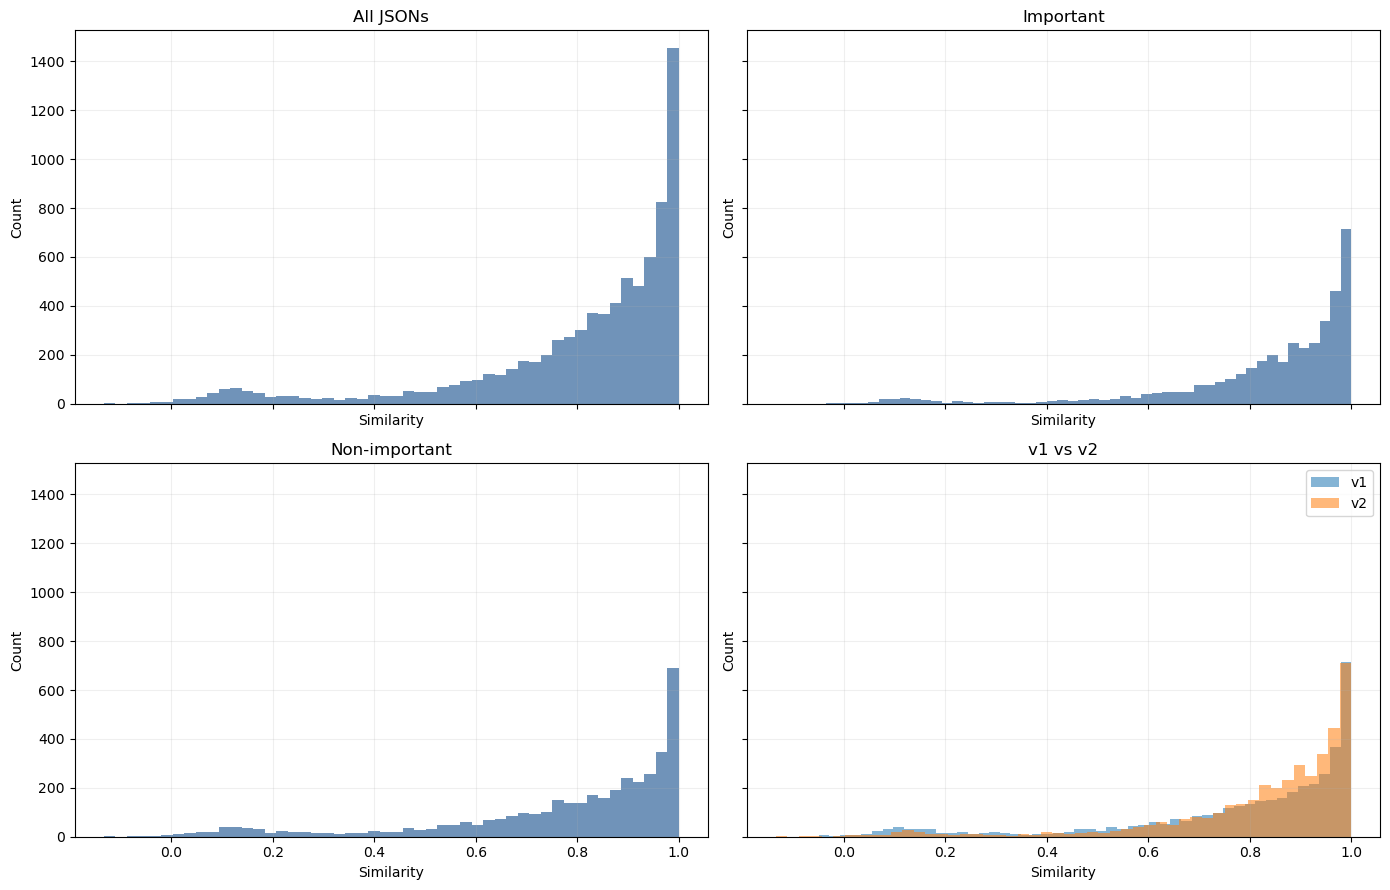

Counts:
all: 7908
important: 3954
non-important: 3954
v1: 3954
v2: 3954


In [24]:

import json
from pathlib import Path

import matplotlib.pyplot as plt

rows = []
for path in DATASET_ROOT.rglob("*.json"):
    try:
        with path.open() as f:
            d = json.load(f)
    except Exception:
        continue

    if not isinstance(d, dict) or "similarity" not in d:
        continue

    try:
        similarity = float(d["similarity"])
    except Exception:
        continue

    label = "unknown"
    if "important-moments" in path.parts:
        label = "important"
    elif "non-important-moments" in path.parts:
        label = "non-important"

    variant = "unknown"
    if path.name.endswith("_v1.json"):
        variant = "v1"
    elif path.name.endswith("_v2.json"):
        variant = "v2"

    rows.append({
        "path": str(path),
        "label": label,
        "variant": variant,
        "similarity": similarity,
    })

df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

plots = [
    ("All JSONs", df),
    ("Important", df[df["label"] == "important"]),
    ("Non-important", df[df["label"] == "non-important"]),
    ("v1 vs v2", None),
]

for ax, (title, subset) in zip(axes.flat, plots):
    if title == "v1 vs v2":
        for variant, color in [("v1", "#1f77b4"), ("v2", "#ff7f0e")]:
            vals = df[df["variant"] == variant]["similarity"]
            ax.hist(vals, bins=50, alpha=0.55, label=variant, color=color)
        ax.legend()
    else:
        ax.hist(subset["similarity"], bins=50, color="#4c78a8", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Similarity")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Counts:")
print("all:", len(df))
print("important:", int((df["label"] == "important").sum()))
print("non-important:", int((df["label"] == "non-important").sum()))
print("v1:", int((df["variant"] == "v1").sum()))
print("v2:", int((df["variant"] == "v2").sum()))

### Suggested next questions

After this notebook, useful next steps are:

1. verify the exact semantic role of source folders `1` and `2`
2. decide whether to use only `v1` or all transcript/audio variants
3. build a clean loader that returns one row per moment clip
4. compute clip durations from `.mp4` and `.wav`
5. reproduce the paper's important vs non-important counts

The paper reports 1977 important and 1977 non-important moments in total. Use this notebook to compare your local copy against that expected size.
